##### DATA 620 Final Project

## Network Analysis of NBA Player Connections Through Shared Team Membership

**Student:** Barakat Adigun  
**Course:** DATA 620 – Web Analytics  
**Project Type:** Final Project

##### Introduction

The National Basketball Association is a highly connected professional league. Players create relationships by sharing team membership, and trades or free-agent moves connect players across franchises and seasons. These relationships can be represented as a network and analyzed using the methods studied in DATA 620.

In this project, each NBA player is represented as a node. Two players are connected when they appeared on the same team during the same season. The edge weight records the number of team-seasons the two players shared.

### Guiding Question

**Which NBA players occupy the most influential positions in the teammate network, and what do those positions reveal about player movement and community structure?**

### Hypothesis

Players with long careers or experience across several franchises will have high degree and betweenness centrality because they accumulate many teammate relationships and connect otherwise separate groups.

##### Data Source and Reproducibility

The analysis uses the regular-season traditional player statistics file from the public GitHub repository **Brescou/NBA-dataset-stats-player-team**. The repository contains NBA player and team statistics from the 1996–97 through 2022–23 seasons.

The notebook first looks for the included local CSV file. If it is not available, it downloads the same file from the repository. The main analysis uses the ten seasons from **2013–14 through 2022–23**. This period is long enough to capture player movement while keeping the projected network computationally manageable.

### Network Definition

- **Bipartite nodes:** NBA players and team-season combinations  
- **Bipartite edges:** A player appeared for a team during a season  
- **Projected player nodes:** NBA players  
- **Projected player edges:** Two players shared at least one team-season  
- **Edge weight:** Number of shared team-seasons

In [70]:
# Import libraries
from pathlib import Path
from itertools import combinations
from collections import Counter

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("pandas version:", pd.__version__)
print("NetworkX version:", nx.__version__)

pandas version: 2.3.3
NetworkX version: 3.5


In [48]:
# Load the dataset from the local project folder.

local_files = [
    Path("nba_player_stats_1996_2023.csv"),
    Path("player_stats_traditionnal_rs.csv")
]

data_path = next((p for p in local_files if p.exists()), None)

if data_path is None:
    data_url = (
        "https://raw.githubusercontent.com/Brescou/"
        "NBA-dataset-stats-player-team/main/player/"
        "player_stats_traditionnal_rs.csv"
    )
    nba_raw = pd.read_csv(data_url)
else:
    nba_raw = pd.read_csv(data_path)

print("Raw dataset shape:", nba_raw.shape)
display(nba_raw.head())

Raw dataset shape: (12846, 67)


,PLAYER_ID,PLAYER_NAME,NICKNAME,TEAM_ID,TEAM_ABBREVIATION,AGE,GP,W,L,W_PCT,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,TOV,STL,BLK,BLKA,PF,PFD,PTS,PLUS_MINUS,NBA_FANTASY_PTS,DD2,TD3,WNBA_FANTASY_PTS,GP_RANK,W_RANK,L_RANK,W_PCT_RANK,MIN_RANK,FGM_RANK,FGA_RANK,FG_PCT_RANK,FG3M_RANK,FG3A_RANK,FG3_PCT_RANK,FTM_RANK,FTA_RANK,FT_PCT_RANK,OREB_RANK,DREB_RANK,REB_RANK,AST_RANK,TOV_RANK,STL_RANK,BLK_RANK,BLKA_RANK,PF_RANK,PFD_RANK,PTS_RANK,PLUS_MINUS_RANK,NBA_FANTASY_PTS_RANK,DD2_RANK,TD3_RANK,WNBA_FANTASY_PTS_RANK,SEASON
0,920,A.C. Green,A.C.,1610612742,DAL,33.0000,83,23,60,0.2770,30.1000,2.8000,5.8000,0.4830,0.0000,0.2000,0.0500,1.5000,2.4000,0.6500,2.7000,5.2000,7.9000,0.8000,0.9000,0.8000,0.2000,0.5000,1.7000,0.0000,7.2000,-4.2000,20.1000,16,0,18.0000,1,238,13,354,117,191,199,101,302,269,302,163,151,318,35,42,43,271,275,145,260,138,251,36,194,394,155,49,24,165,1996-97
1,243,Aaron McKie,Aaron,1610612765,DET,24.0000,83,48,35,0.5780,19.6000,1.8000,4.4000,0.4110,0.5000,1.2000,0.3980,1.1000,1.3000,0.8360,0.5000,2.2000,2.7000,1.9000,1.1000,0.9000,0.3000,0.4000,1.6000,0.0000,5.2000,1.6000,13.8000,1,0,12.7000,1,67,132,158,211,264,258,302,158,172,63,220,252,60,315,199,229,151,222,116,213,176,285,192,248,93,229,168,24,233,1996-97
2,1425,Aaron Williams,Aaron,1610612763,VAN,25.0000,33,4,29,0.1210,17.0000,2.6000,4.5000,0.5740,0.0000,0.0000,0.0000,1.0000,1.5000,0.6730,1.9000,2.5000,4.3000,0.5000,1.0000,0.5000,0.9000,0.2000,2.2000,0.0000,6.2000,-3.2000,15.2000,0,0,13.7000,329,392,177,425,241,202,253,8,303,342,303,237,231,296,83,170,125,343,253,266,58,319,182,192,224,363,207,219,24,213,1996-97
3,768,Acie Earl,Acie,1610612749,MIL,27.0000,47,14,33,0.2980,10.6000,1.4000,3.8000,0.3740,0.0000,0.1000,0.0000,1.1000,1.8000,0.6430,0.7000,1.3000,2.0000,0.4000,0.7000,0.3000,0.6000,0.2000,1.3000,0.0000,4.0000,-1.3000,9.1000,0,0,8.3000,287,308,146,342,343,304,289,381,303,297,303,209,189,324,244,302,278,351,304,338,96,357,329,192,292,269,304,219,24,307,1996-97
4,228,Adam Keefe,Adam,1610612762,UTA,27.0000,62,48,14,0.7740,14.8000,1.3000,2.6000,0.5130,0.0000,0.0000,0.0000,1.1000,1.7000,0.6890,1.2000,2.3000,3.5000,0.5000,0.7000,0.5000,0.2000,0.2000,1.6000,0.0000,3.8000,2.0000,10.1000,1,0,9.2000,215,67,320,39,278,320,351,52,303,357,303,211,202,278,156,186,172,327,313,267,250,320,286,125,305,77,282,168,24,288,1996-97


### Initial Interpretation

The file contains one or more player-team records per season. Players who changed teams during a season may appear more than once, which is useful for this project because each team membership creates a separate network relationship. The analysis keeps only the columns needed to identify players, teams, seasons, and games played.

In [49]:
# Inspect relevant columns and season coverage
relevant_columns = [
    "PLAYER_ID", "PLAYER_NAME", "TEAM_ID",
    "TEAM_ABBREVIATION", "GP", "SEASON"
]

display(nba_raw[relevant_columns].head())
print("Earliest season:", nba_raw["SEASON"].min())
print("Latest season:", nba_raw["SEASON"].max())
print("Number of seasons:", nba_raw["SEASON"].nunique())
print("Missing values in relevant columns:")
display(nba_raw[relevant_columns].isna().sum().to_frame("missing"))

,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_ABBREVIATION,GP,SEASON
0,920,A.C. Green,1610612742,DAL,83,1996-97
1,243,Aaron McKie,1610612765,DET,83,1996-97
2,1425,Aaron Williams,1610612763,VAN,33,1996-97
3,768,Acie Earl,1610612749,MIL,47,1996-97
4,228,Adam Keefe,1610612762,UTA,62,1996-97


Earliest season: 1996-97
Latest season: 2022-23
Number of seasons: 27
Missing values in relevant columns:


,missing
PLAYER_ID,0
PLAYER_NAME,0
TEAM_ID,0
TEAM_ABBREVIATION,0
GP,0
SEASON,0


## Data Cleaning

The following steps prepare the data for network construction:

1. Select the 2013–14 through 2022–23 seasons.
2. Keep valid player, team, and season records.
3. Remove exact duplicate player-team-season rows.
4. Require at least one game played.
5. Create a unique `TEAM_SEASON` identifier.
6. Use `PLAYER_ID` as the graph identifier while retaining player names as labels.

Using player IDs prevents problems when two players have similar names.

In [50]:
START_SEASON = "2013-14"
END_SEASON = "2022-23"

nba = (
    nba_raw.loc[
        nba_raw["SEASON"].between(START_SEASON, END_SEASON),
        relevant_columns
    ]
    .dropna(subset=["PLAYER_ID", "PLAYER_NAME", "TEAM_ABBREVIATION", "SEASON"])
    .query("GP > 0")
    .drop_duplicates(
        subset=["PLAYER_ID", "TEAM_ABBREVIATION", "SEASON"]
    )
    .copy()
)

nba["PLAYER_ID"] = nba["PLAYER_ID"].astype(int)
nba["TEAM_SEASON"] = (
    nba["TEAM_ABBREVIATION"].astype(str)
    + "_"
    + nba["SEASON"].astype(str)
)

print("Cleaned player-team-season rows:", len(nba))
print("Unique players:", nba["PLAYER_ID"].nunique())
print("Unique team-seasons:", nba["TEAM_SEASON"].nunique())
print("Seasons analyzed:", nba["SEASON"].nunique())
display(nba.head())

Cleaned player-team-season rows: 5219
Unique players: 1398
Unique team-seasons: 300
Seasons analyzed: 10


,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_ABBREVIATION,GP,SEASON,TEAM_SEASON
7627,201985,AJ Price,1610612750,MIN,28,2013-14,MIN_2013-14
7628,201166,Aaron Brooks,1610612743,DEN,72,2013-14,DEN_2013-14
7629,201189,Aaron Gray,1610612758,SAC,37,2013-14,SAC_2013-14
7630,203519,Adonis Thomas,1610612755,PHI,6,2013-14,PHI_2013-14
7631,1733,Al Harrington,1610612764,WAS,34,2013-14,WAS_2013-14


In [51]:
# Summarize the number of players and teams represented in each season
season_summary = (
    nba.groupby("SEASON")
       .agg(
           player_team_records=("PLAYER_ID", "size"),
           unique_players=("PLAYER_ID", "nunique"),
           teams=("TEAM_ABBREVIATION", "nunique")
       )
       .reset_index()
)

display(season_summary)

,SEASON,player_team_records,unique_players,teams
0,2013-14,482,482,30
1,2014-15,492,492,30
2,2015-16,476,476,30
3,2016-17,486,486,30
4,2017-18,540,540,30
5,2018-19,530,530,30
6,2019-20,529,529,30
7,2020-21,540,540,30
8,2021-22,605,605,30
9,2022-23,539,539,30


### Cleaning Interpretation

The cleaned data preserves every valid team assignment. Therefore, a player traded during a season can connect the roster communities of multiple teams. This is an important feature rather than a duplicate-data problem because player movement is one of the mechanisms that joins the NBA network.

## Step 1: Construct the Bipartite Network

The bipartite graph contains two different node types:

- Player nodes
- Team-season nodes

An edge indicates that a player appeared for that team during that season. This graph directly represents the structure of the source data before projection.

In [52]:
# Create the bipartite player/team-season graph
B = nx.Graph()

player_name_map = (
    nba.drop_duplicates("PLAYER_ID")
       .set_index("PLAYER_ID")["PLAYER_NAME"]
       .to_dict()
)

player_ids = set(nba["PLAYER_ID"])
team_seasons = set(nba["TEAM_SEASON"])

B.add_nodes_from(
    player_ids,
    bipartite="player",
    label="player"
)
B.add_nodes_from(
    team_seasons,
    bipartite="team_season",
    label="team_season"
)

B.add_edges_from(
    nba[["PLAYER_ID", "TEAM_SEASON"]]
    .itertuples(index=False, name=None)
)

print("Bipartite nodes:", B.number_of_nodes())
print("Bipartite edges:", B.number_of_edges())
print("Player nodes:", len(player_ids))
print("Team-season nodes:", len(team_seasons))
print("Is the graph bipartite?", nx.is_bipartite(B))

Bipartite nodes: 1698
Bipartite edges: 5219
Player nodes: 1398
Team-season nodes: 300
Is the graph bipartite? True


### Bipartite Interpretation

A player connected to many team-season nodes either had a long career during the period, changed teams frequently, or both. However, the main research question concerns player-to-player relationships. The next step projects the bipartite graph onto the player node set.

## Step 2: Create the Weighted Player Projection

In the player projection, two players are connected if they shared a team-season. Rather than using a simple unweighted edge, the project counts how many team-seasons the pair shared. A larger edge weight represents a repeated teammate relationship.

In [53]:
# Build a weighted player projection efficiently by examining each roster.
# This produces the same concept as a weighted bipartite projection:
# each shared team-season contributes 1 to the player-pair edge weight.

G = nx.Graph()

for player_id, player_name in player_name_map.items():
    G.add_node(player_id, name=player_name)

for team_season, roster in nba.groupby("TEAM_SEASON"):
    roster_ids = sorted(roster["PLAYER_ID"].unique())
    for u, v in combinations(roster_ids, 2):
        if G.has_edge(u, v):
            G[u][v]["weight"] += 1
            G[u][v]["team_seasons"].append(team_season)
        else:
            G.add_edge(
                u, v,
                weight=1,
                team_seasons=[team_season]
            )

# Remove isolates, if any
G.remove_nodes_from(list(nx.isolates(G)))

print("Projected player nodes:", G.number_of_nodes())
print("Projected player edges:", G.number_of_edges())
print("Connected components:", nx.number_connected_components(G))
print("Largest component size:",
      len(max(nx.connected_components(G), key=len)))

Projected player nodes: 1398
Projected player edges: 34141
Connected components: 1
Largest component size: 1398


In [54]:
# Basic network statistics
n = G.number_of_nodes()
m = G.number_of_edges()

network_summary = pd.DataFrame({
    "Metric": [
        "Number of players",
        "Number of teammate relationships",
        "Network density",
        "Average degree",
        "Average clustering coefficient",
        "Number of connected components"
    ],
    "Value": [
        n,
        m,
        nx.density(G),
        sum(dict(G.degree()).values()) / n,
        nx.average_clustering(G),
        nx.number_connected_components(G)
    ]
})

display(network_summary)

,Metric,Value
0,Number of players,"1,398.0000"
1,Number of teammate relationships,"34,141.0000"
2,Network density,0.0350
3,Average degree,48.8426
4,Average clustering coefficient,0.5635
5,Number of connected components,1.0000


### Network-Level Interpretation

Network density measures the share of all theoretically possible player connections that actually exist. A low density is expected because most NBA players share rosters with only a small fraction of all players in the ten-season period. The average clustering coefficient is especially meaningful: teammate networks naturally form triangles because members of the same roster are mutually connected.

## Step 3: Examine Degree and Edge Weights

Unweighted degree counts the number of distinct teammates a player had. Weighted degree, also called node strength, adds the weights of all adjacent edges and gives additional credit for repeated shared team-seasons.

In [55]:
degree = dict(G.degree())
weighted_degree = dict(G.degree(weight="weight"))

degree_table = pd.DataFrame({
    "PLAYER_ID": list(G.nodes()),
    "Player": [G.nodes[node]["name"] for node in G.nodes()],
    "Distinct Teammates": [degree[node] for node in G.nodes()],
    "Weighted Degree": [weighted_degree[node] for node in G.nodes()]
}).sort_values(
    ["Distinct Teammates", "Weighted Degree"],
    ascending=False
).reset_index(drop=True)

display(degree_table.head(15))

,PLAYER_ID,Player,Distinct Teammates,Weighted Degree
0,201145,Jeff Green,152,171
1,200765,Rajon Rondo,140,151
2,201580,JaVale McGee,138,169
3,203552,Seth Curry,138,152
4,200782,P.J. Tucker,136,172
5,203516,James Ennis III,136,143
6,201577,Robin Lopez,133,162
7,203463,Ben McLemore,133,155
8,203085,Austin Rivers,132,171
9,203200,Justin Holiday,132,154


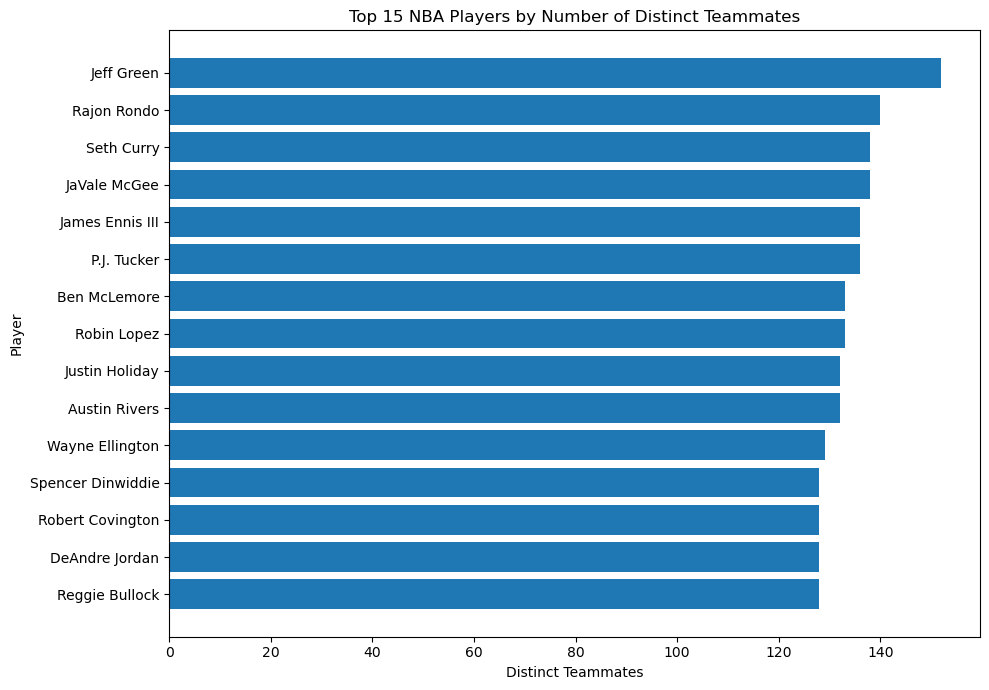

In [56]:
# Plot the top 15 players by number of distinct teammates
top_degree = degree_table.head(15).sort_values("Distinct Teammates")

plt.figure(figsize=(10, 7))
plt.barh(top_degree["Player"], top_degree["Distinct Teammates"])
plt.title("Top 15 NBA Players by Number of Distinct Teammates")
plt.xlabel("Distinct Teammates")
plt.ylabel("Player")
plt.tight_layout()
plt.show()

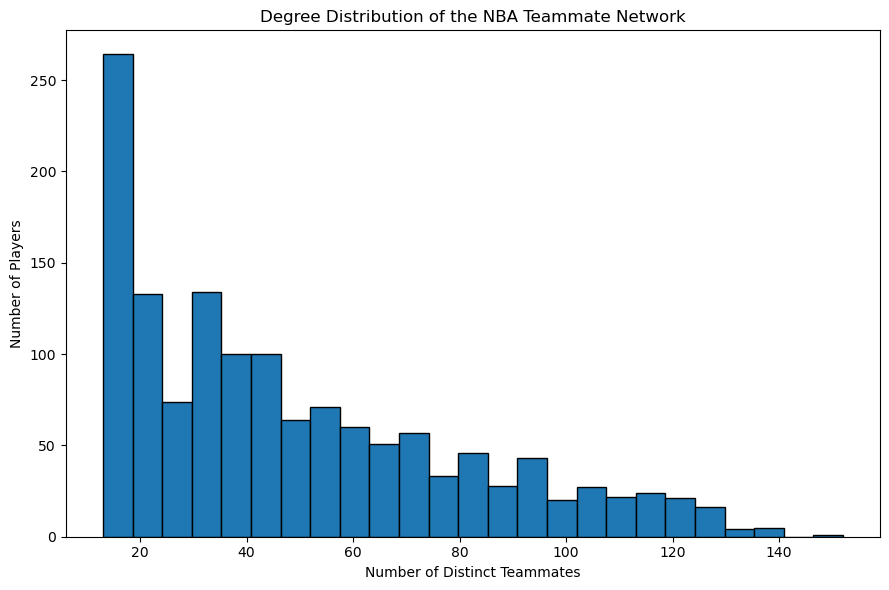

In [57]:
# Degree distribution
degree_values = list(degree.values())

plt.figure(figsize=(9, 6))
plt.hist(degree_values, bins=25, edgecolor="black")
plt.title("Degree Distribution of the NBA Teammate Network")
plt.xlabel("Number of Distinct Teammates")
plt.ylabel("Number of Players")
plt.tight_layout()
plt.show()

### Degree Interpretation

Players at the top of the degree table had the largest number of distinct teammates during the selected period. High degree may result from a long career, frequent team changes, or participation on rosters with substantial turnover. It measures reach within the teammate network, not on-court quality.

## Step 4: Centrality Analysis

Several measures are used because influence has more than one meaning:

- **Degree centrality:** Share of players directly connected to a player.
- **Betweenness centrality:** Frequency with which a player lies on shortest paths between others.
- **Closeness centrality:** How near a player is to all other reachable players.
- **Eigenvector centrality:** Gives more importance to connections with other highly connected players.

Exact betweenness can be computationally expensive. This notebook uses a reproducible approximation based on 150 sampled nodes, which is appropriate for exploratory analysis of a network of this size.

In [58]:
# Centrality calculations
degree_centrality = nx.degree_centrality(G)

# Reproducible approximation to reduce computation time
sample_k = min(150, G.number_of_nodes())
betweenness_centrality = nx.betweenness_centrality(
    G,
    k=sample_k,
    normalized=True,
    weight=None,
    seed=620
)

closeness_centrality = nx.closeness_centrality(G)

try:
    eigenvector_centrality = nx.eigenvector_centrality(
        G,
        max_iter=2000,
        tol=1e-08,
        weight="weight"
    )
except nx.PowerIterationFailedConvergence:
    eigenvector_centrality = nx.eigenvector_centrality_numpy(
        G,
        weight="weight"
    )

centrality = pd.DataFrame({
    "PLAYER_ID": list(G.nodes()),
    "Player": [G.nodes[node]["name"] for node in G.nodes()],
    "Degree Centrality": [degree_centrality[node] for node in G.nodes()],
    "Betweenness Centrality": [
        betweenness_centrality[node] for node in G.nodes()
    ],
    "Closeness Centrality": [
        closeness_centrality[node] for node in G.nodes()
    ],
    "Eigenvector Centrality": [
        eigenvector_centrality[node] for node in G.nodes()
    ]
})

# Rank each player on every measure and calculate a combined average rank.
for metric in [
    "Degree Centrality",
    "Betweenness Centrality",
    "Closeness Centrality",
    "Eigenvector Centrality"
]:
    centrality[f"{metric} Rank"] = (
        centrality[metric]
        .rank(method="min", ascending=False)
    )

rank_columns = [
    col for col in centrality.columns if col.endswith("Rank")
]
centrality["Average Rank"] = centrality[rank_columns].mean(axis=1)

display(
    centrality.sort_values("Average Rank")
              .head(15)
              .reset_index(drop=True)
)

,PLAYER_ID,Player,Degree Centrality,Betweenness Centrality,Closeness Centrality,Eigenvector Centrality,Degree Centrality Rank,Betweenness Centrality Rank,Closeness Centrality Rank,Eigenvector Centrality Rank,Average Rank
0,201145,Jeff Green,0.1088,0.0069,0.5076,0.0640,1.0000,12.0000,3.0000,12.0000,7.0000
1,200782,P.J. Tucker,0.0974,0.0060,0.5051,0.0682,5.0000,26.0000,10.0000,2.0000,10.7500
2,202693,Markieff Morris,0.0902,0.0055,0.5042,0.0664,21.0000,35.0000,15.0000,6.0000,19.2500
3,203085,Austin Rivers,0.0945,0.0072,0.4982,0.0618,9.0000,9.0000,39.0000,22.0000,19.7500
4,203552,Seth Curry,0.0988,0.0068,0.5063,0.0562,3.0000,16.0000,4.0000,62.0000,21.2500
5,2544,LeBron James,0.0859,0.0078,0.4991,0.0653,42.0000,8.0000,32.0000,10.0000,23.0000
6,201566,Russell Westbrook,0.0873,0.0058,0.5020,0.0630,32.0000,29.0000,22.0000,15.0000,24.5000
7,202397,Ish Smith,0.0909,0.0063,0.5038,0.0582,17.0000,21.0000,18.0000,44.0000,25.0000
8,201933,Blake Griffin,0.0880,0.0062,0.4991,0.0629,27.0000,24.0000,32.0000,17.0000,25.0000
9,201599,DeAndre Jordan,0.0916,0.0070,0.4949,0.0614,12.0000,11.0000,58.0000,24.0000,26.2500


In [59]:
def top_metric_table(metric, n=10):
    return (
        centrality[["Player", metric]]
        .sort_values(metric, ascending=False)
        .head(n)
        .reset_index(drop=True)
    )

print("Top players by degree centrality")
display(top_metric_table("Degree Centrality"))

print("Top players by betweenness centrality")
display(top_metric_table("Betweenness Centrality"))

print("Top players by closeness centrality")
display(top_metric_table("Closeness Centrality"))

print("Top players by eigenvector centrality")
display(top_metric_table("Eigenvector Centrality"))

Top players by degree centrality


,Player,Degree Centrality
0,Jeff Green,0.1088
1,Rajon Rondo,0.1002
2,Seth Curry,0.0988
3,JaVale McGee,0.0988
4,James Ennis III,0.0974
5,P.J. Tucker,0.0974
6,Robin Lopez,0.0952
7,Ben McLemore,0.0952
8,Justin Holiday,0.0945
9,Austin Rivers,0.0945


Top players by betweenness centrality


,Player,Betweenness Centrality
0,Boban Marjanovic,0.0124
1,Alec Burks,0.0089
2,D.J. Augustin,0.0086
3,Mike Muscala,0.0083
4,Ben McLemore,0.0083
5,Jerami Grant,0.0081
6,Steven Adams,0.0079
7,LeBron James,0.0078
8,Austin Rivers,0.0072
9,Bojan Bogdanovic,0.0071


Top players by closeness centrality


,Player,Closeness Centrality
0,Dwight Howard,0.5108
1,Ben McLemore,0.5097
2,Jeff Green,0.5076
3,Robert Covington,0.5063
4,Wesley Matthews,0.5063
5,Garrett Temple,0.5063
6,Seth Curry,0.5063
7,Wayne Ellington,0.5062
8,Robin Lopez,0.5058
9,P.J. Tucker,0.5051


Top players by eigenvector centrality


,Player,Eigenvector Centrality
0,Kyrie Irving,0.0703
1,P.J. Tucker,0.0682
2,Khris Middleton,0.0671
3,Giannis Antetokounmpo,0.0671
4,Serge Ibaka,0.0668
5,Markieff Morris,0.0664
6,Wesley Matthews,0.0660
7,Reggie Bullock,0.0660
8,Marcus Morris Sr.,0.0656
9,LeBron James,0.0653


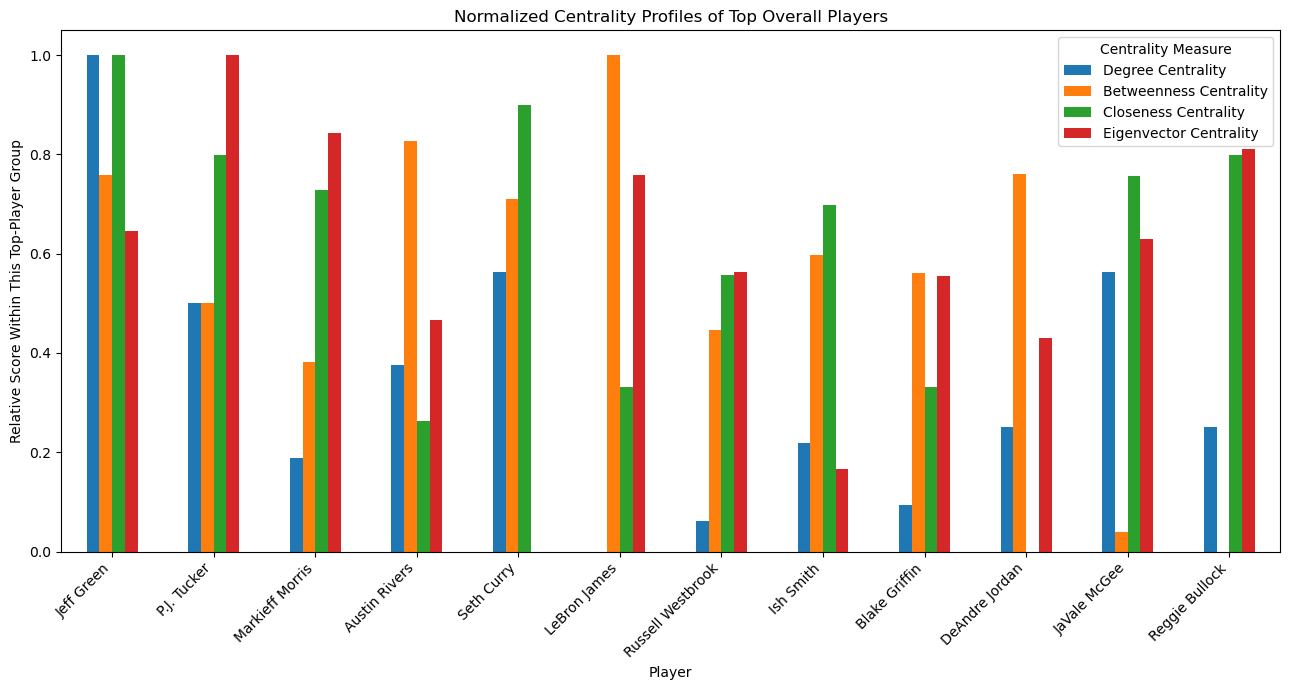

In [60]:
# Compare the four centrality measures for the strongest overall players
top_overall = (
    centrality.sort_values("Average Rank")
              .head(12)
              .set_index("Player")
)

plot_data = top_overall[
    [
        "Degree Centrality",
        "Betweenness Centrality",
        "Closeness Centrality",
        "Eigenvector Centrality"
    ]
]

# Scale each column from 0 to 1 for a readable comparison
scaled_plot_data = (
    plot_data - plot_data.min()
) / (
    plot_data.max() - plot_data.min()
)

scaled_plot_data.plot(
    kind="bar",
    figsize=(13, 7)
)
plt.title("Normalized Centrality Profiles of Top Overall Players")
plt.xlabel("Player")
plt.ylabel("Relative Score Within This Top-Player Group")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Centrality Measure")
plt.tight_layout()
plt.show()

### Centrality Interpretation

The centrality measures answer different questions. Degree identifies players with many direct teammate relationships. Betweenness is particularly useful for the hypothesis because a high score suggests that a player helps connect groups created by different teams or eras. Eigenvector centrality highlights players embedded in strongly connected portions of the league.

The combined rank is not an official network statistic. It is a transparent summary used to compare players across the four measures without claiming that one measure is universally best.

## Step 5: Community Detection and Model Evaluation

Communities are groups of players with denser internal connections than external connections. The project uses the Louvain algorithm implemented in NetworkX.

Because community detection is a modeling choice, its quality is evaluated using **modularity**. Modularity compares the observed concentration of within-community edges with what would be expected under a network with a similar degree structure. Higher values indicate a clearer community division.

The resolution parameter controls community size. Several candidate values are compared, and the solution with the highest modularity is selected.

In [61]:
# Compare several Louvain resolution parameters
resolution_results = []
candidate_resolutions = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]

for resolution in candidate_resolutions:
    communities_candidate = nx.community.louvain_communities(
        G,
        weight="weight",
        resolution=resolution,
        seed=620
    )
    modularity = nx.community.modularity(
        G,
        communities_candidate,
        weight="weight",
        resolution=resolution
    )
    resolution_results.append({
        "Resolution": resolution,
        "Communities": len(communities_candidate),
        "Modularity": modularity
    })

resolution_table = pd.DataFrame(resolution_results)
display(resolution_table)

best_resolution = (
    resolution_table.sort_values(
        ["Modularity", "Communities"],
        ascending=[False, True]
    )
    .iloc[0]["Resolution"]
)

communities = nx.community.louvain_communities(
    G,
    weight="weight",
    resolution=float(best_resolution),
    seed=620
)

best_modularity = nx.community.modularity(
    G,
    communities,
    weight="weight",
    resolution=float(best_resolution)
)

print("Selected resolution:", best_resolution)
print("Number of communities:", len(communities))
print("Modularity:", round(best_modularity, 4))

,Resolution,Communities,Modularity
0,0.5000,3,0.5063
1,0.7500,10,0.4229
2,1.0000,18,0.3993
3,1.2500,23,0.3852
4,1.5000,26,0.3716
5,2.0000,37,0.3514


Selected resolution: 0.5
Number of communities: 3
Modularity: 0.5063


In [62]:
# Assign community labels and summarize the largest groups
community_map = {
    node: community_id
    for community_id, members in enumerate(communities, start=1)
    for node in members
}

nx.set_node_attributes(G, community_map, "community")

community_rows = []
for community_id, members in enumerate(communities, start=1):
    member_list = list(members)
    top_members = sorted(
        member_list,
        key=lambda node: degree[node],
        reverse=True
    )[:8]

    community_rows.append({
        "Community": community_id,
        "Size": len(member_list),
        "Top Players by Degree": ", ".join(
            G.nodes[node]["name"] for node in top_members
        )
    })

community_summary = (
    pd.DataFrame(community_rows)
      .sort_values("Size", ascending=False)
      .reset_index(drop=True)
)

display(community_summary.head(12))

,Community,Size,Top Players by Degree
0,1,1338,"Jeff Green, Rajon Rondo, JaVale McGee, Seth Cu..."
1,2,30,"Shai Gilgeous-Alexander, Ty Jerome, Kenrich Wi..."
2,3,30,"Tyus Jones, Dillon Brooks, De'Anthony Melton, ..."


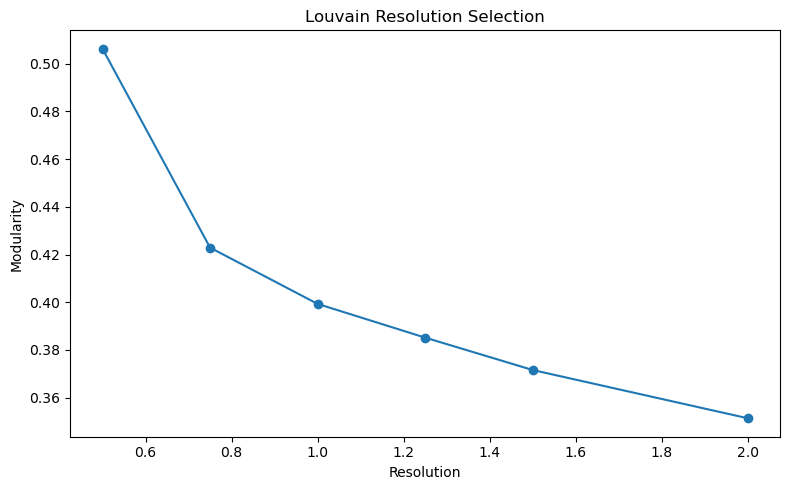

In [63]:
# Plot modularity across candidate resolutions
plt.figure(figsize=(8, 5))
plt.plot(
    resolution_table["Resolution"],
    resolution_table["Modularity"],
    marker="o"
)
plt.title("Louvain Resolution Selection")
plt.xlabel("Resolution")
plt.ylabel("Modularity")
plt.tight_layout()
plt.show()

### Community Interpretation

Communities in this network should not automatically be interpreted as formal NBA divisions or exact team rosters. They are emergent groups produced by repeated teammate relationships across seasons. A community may be centered on a stable franchise core, while bridge players can connect it to other communities after trades or free-agent moves.

The selected resolution is justified by the highest modularity among the tested candidate settings. This provides an explicit evaluation of the community-detection parameters rather than choosing a value only because the visualization looks attractive.

## Step 6: Network Visualization

Displaying every edge would produce an unreadable “hairball.” The visualization therefore focuses on the 80 players with the highest degree. It preserves edges among those players and uses node size to represent degree and node color to represent the detected community.

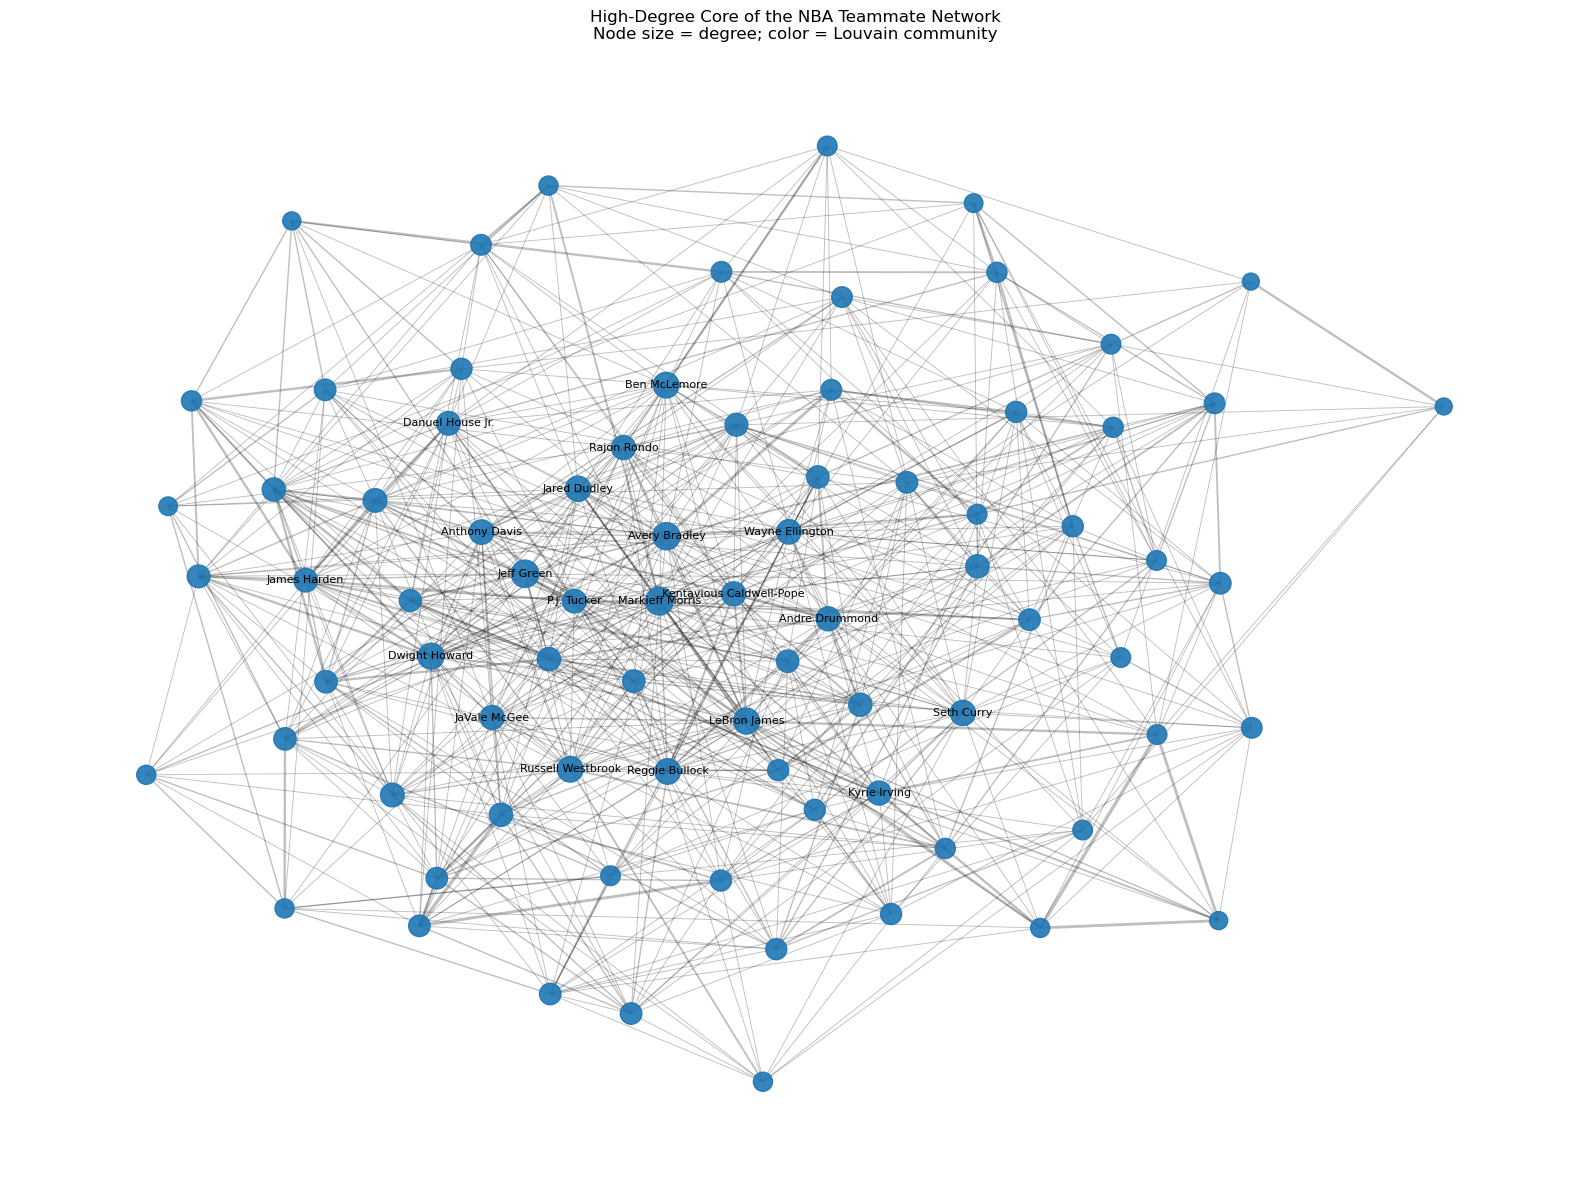

In [64]:
# Visualize the high-degree core of the network
top_nodes = [
    node for node, value in
    sorted(degree.items(), key=lambda item: item[1], reverse=True)[:80]
]

H = G.subgraph(top_nodes).copy()

pos = nx.spring_layout(
    H,
    seed=620,
    k=0.65,
    weight="weight",
    iterations=100
)

node_sizes = [
    80 + 10 * H.degree(node)
    for node in H.nodes()
]
node_colors = [
    community_map[node]
    for node in H.nodes()
]
edge_widths = [
    0.3 + 0.35 * H[u][v]["weight"]
    for u, v in H.edges()
]

# Label only the 20 highest-degree players in this subgraph
label_nodes = sorted(
    H.nodes(),
    key=lambda node: H.degree(node),
    reverse=True
)[:20]
labels = {
    node: H.nodes[node]["name"]
    for node in label_nodes
}

plt.figure(figsize=(16, 12))
nx.draw_networkx_edges(
    H,
    pos,
    width=edge_widths,
    alpha=0.25
)
nx.draw_networkx_nodes(
    H,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.tab20,
    alpha=0.9
)
nx.draw_networkx_labels(
    H,
    pos,
    labels=labels,
    font_size=8
)
plt.title(
    "High-Degree Core of the NBA Teammate Network\n"
    "Node size = degree; color = Louvain community"
)
plt.axis("off")
plt.tight_layout()
plt.show()

### Visualization Interpretation

The visualization emphasizes the core of the network while avoiding unnecessary visual clutter. Large nodes represent players with many direct teammate relationships. Players located between differently colored clusters may have served as bridges through team changes. The image should be interpreted together with the quantitative centrality tables rather than as standalone proof of importance.

## Step 7: Test the Hypothesis

The hypothesis predicts that players with longer careers and experience with more franchises will be more central. The dataset does not contain complete career history after 2022–23, so the test is limited to the selected ten-season observation window.

For each player, the analysis calculates:

- Number of seasons represented
- Number of distinct teams represented
- Number of player-team-season records
- Degree
- Betweenness centrality

Spearman rank correlations are used because these variables are counts and their relationships do not need to be linear.

In [65]:
# Create player-level career movement measures within the analysis window
player_history = (
    nba.groupby(["PLAYER_ID", "PLAYER_NAME"])
       .agg(
           Seasons=("SEASON", "nunique"),
           Teams=("TEAM_ABBREVIATION", "nunique"),
           Team_Season_Records=("TEAM_SEASON", "nunique"),
           Total_Games=("GP", "sum")
       )
       .reset_index()
)

hypothesis_data = (
    player_history.merge(
        centrality[
            [
                "PLAYER_ID",
                "Degree Centrality",
                "Betweenness Centrality",
                "Eigenvector Centrality"
            ]
        ],
        on="PLAYER_ID",
        how="inner"
    )
)

correlations = (
    hypothesis_data[
        [
            "Seasons",
            "Teams",
            "Team_Season_Records",
            "Degree Centrality",
            "Betweenness Centrality",
            "Eigenvector Centrality"
        ]
    ]
    .corr(method="spearman")
)

display(correlations)

,Seasons,Teams,Team_Season_Records,Degree Centrality,Betweenness Centrality,Eigenvector Centrality
Seasons,1.0000,0.7641,1.0000,0.9665,0.9459,0.9744
Teams,0.7641,1.0000,0.7641,0.8383,0.8513,0.7567
Team_Season_Records,1.0000,0.7641,1.0000,0.9665,0.9459,0.9744
Degree Centrality,0.9665,0.8383,0.9665,1.0000,0.9658,0.9552
Betweenness Centrality,0.9459,0.8513,0.9459,0.9658,1.0000,0.9174
Eigenvector Centrality,0.9744,0.7567,0.9744,0.9552,0.9174,1.0000


In [66]:
# Display players with the most teams during the study window
movement_table = (
    hypothesis_data.sort_values(
        ["Teams", "Seasons", "Degree Centrality"],
        ascending=False
    )
    .head(15)
    .reset_index(drop=True)
)

display(
    movement_table[
        [
            "PLAYER_NAME",
            "Seasons",
            "Teams",
            "Team_Season_Records",
            "Degree Centrality",
            "Betweenness Centrality"
        ]
    ]
)

,PLAYER_NAME,Seasons,Teams,Team_Season_Records,Degree Centrality,Betweenness Centrality
0,Jeff Green,10,9,10,0.1088,0.0069
1,Rajon Rondo,9,8,9,0.1002,0.0062
2,Robin Lopez,10,7,10,0.0952,0.0045
3,James Johnson,10,7,10,0.0909,0.0037
4,Seth Curry,9,7,9,0.0988,0.0068
5,Justin Holiday,9,7,9,0.0945,0.0050
6,Isaiah Thomas,9,7,9,0.0845,0.0067
7,Ed Davis,9,7,9,0.0838,0.0052
8,James Ennis III,8,7,8,0.0974,0.0061
9,Tim Frazier,8,7,8,0.0916,0.0051


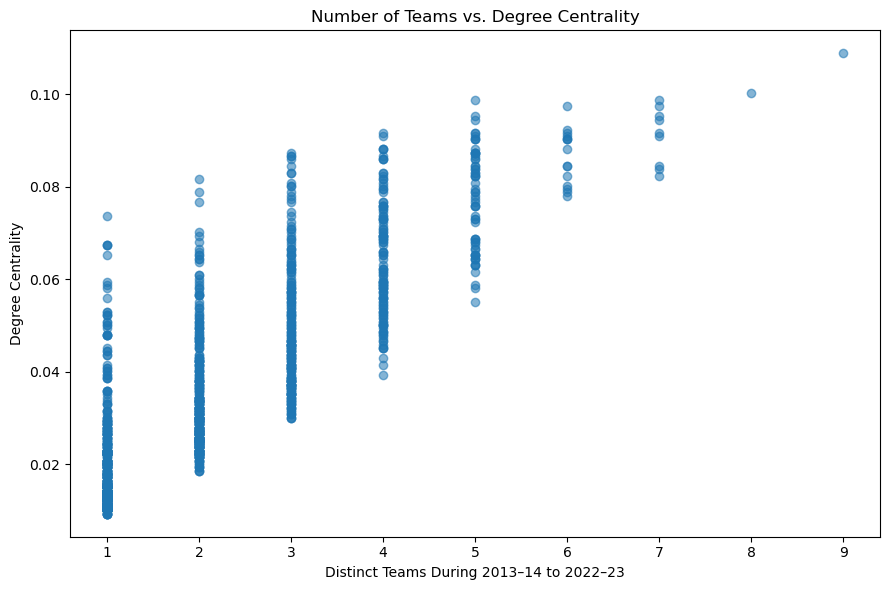

In [67]:
# Scatter plot: team movement versus degree centrality
plt.figure(figsize=(9, 6))
plt.scatter(
    hypothesis_data["Teams"],
    hypothesis_data["Degree Centrality"],
    alpha=0.55
)
plt.title("Number of Teams vs. Degree Centrality")
plt.xlabel("Distinct Teams During 2013–14 to 2022–23")
plt.ylabel("Degree Centrality")
plt.tight_layout()
plt.show()

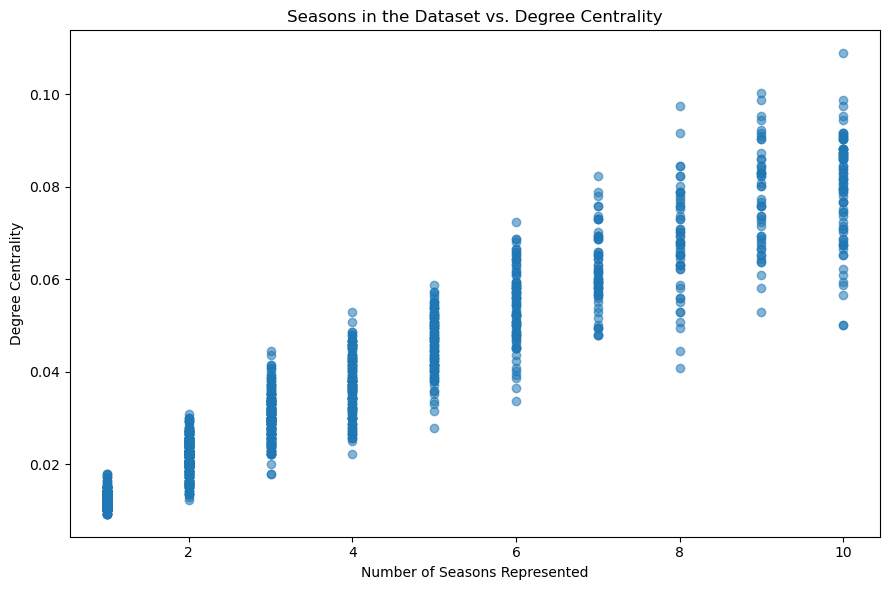

In [68]:
# Scatter plot: number of seasons versus degree centrality
plt.figure(figsize=(9, 6))
plt.scatter(
    hypothesis_data["Seasons"],
    hypothesis_data["Degree Centrality"],
    alpha=0.55
)
plt.title("Seasons in the Dataset vs. Degree Centrality")
plt.xlabel("Number of Seasons Represented")
plt.ylabel("Degree Centrality")
plt.tight_layout()
plt.show()

### Hypothesis Interpretation

A positive Spearman correlation between centrality and either seasons or teams supports the hypothesis. The relationship is not expected to be perfect. A player can remain with one franchise for many years and still accumulate many teammates because roster turnover occurs around the player. Conversely, a frequently traded player may join small or overlapping groups and not achieve the highest centrality.

Therefore, career length and team movement should be viewed as important structural explanations rather than the only causes of network influence.

## Step 8: Strongest Teammate Relationships

Edge weight records how many team-seasons two players shared. Examining the strongest edges identifies stable teammate partnerships during the ten-season period.

In [69]:
strongest_edges = sorted(
    G.edges(data=True),
    key=lambda edge: edge[2]["weight"],
    reverse=True
)[:20]

strongest_teammates = pd.DataFrame([
    {
        "Player 1": G.nodes[u]["name"],
        "Player 2": G.nodes[v]["name"],
        "Shared Team-Seasons": data["weight"],
        "Team-Seasons": ", ".join(data["team_seasons"])
    }
    for u, v, data in strongest_edges
])

display(strongest_teammates)

,Player 1,Player 2,Shared Team-Seasons,Team-Seasons
0,Draymond Green,Stephen Curry,10,"GSW_2013-14, GSW_2014-15, GSW_2015-16, GSW_201..."
1,Giannis Antetokounmpo,Khris Middleton,10,"MIL_2013-14, MIL_2014-15, MIL_2015-16, MIL_201..."
2,Andre Iguodala,Stephen Curry,8,"GSW_2013-14, GSW_2014-15, GSW_2015-16, GSW_201..."
3,Andre Iguodala,Klay Thompson,8,"GSW_2013-14, GSW_2014-15, GSW_2015-16, GSW_201..."
4,Andre Iguodala,Draymond Green,8,"GSW_2013-14, GSW_2014-15, GSW_2015-16, GSW_201..."
5,CJ McCollum,Damian Lillard,8,"POR_2013-14, POR_2014-15, POR_2015-16, POR_201..."
6,Draymond Green,Klay Thompson,8,"GSW_2013-14, GSW_2014-15, GSW_2015-16, GSW_201..."
7,Draymond Green,Kevon Looney,8,"GSW_2015-16, GSW_2016-17, GSW_2017-18, GSW_201..."
8,Klay Thompson,Stephen Curry,8,"GSW_2013-14, GSW_2014-15, GSW_2015-16, GSW_201..."
9,Stephen Curry,Kevon Looney,8,"GSW_2015-16, GSW_2016-17, GSW_2017-18, GSW_201..."


### Edge-Weight Interpretation

The strongest edges represent players who remained teammates across many seasons. These relationships differ from high degree: a player can have a very strong connection to a small number of long-term teammates while another player can have many one-season teammate relationships.

## Findings and Discussion

The final interpretation should be based on the executed tables above. In general, the project answers the research question in four ways:

1. **Degree centrality** identifies players with the broadest direct teammate reach.
2. **Betweenness centrality** identifies players who connect different parts of the network.
3. **Eigenvector centrality** identifies players embedded among other highly connected players.
4. **Community detection** reveals groups formed by dense patterns of shared team membership.

The results should not be interpreted as a ranking of basketball ability. Network position reflects roster relationships, career duration, player movement, and organizational turnover. A role player who moved through many teams may be structurally central even without elite individual statistics.

The findings can support sports analytics by showing how player movement transfers experience and relationships across franchises. The same framework could be expanded to compare eras, study championship teams, or evaluate whether bridge players contribute to the diffusion of playing styles.

## Limitations

This analysis has several limitations:

- The source file ends with the 2022–23 season.
- A shared roster does not prove that two players spent meaningful minutes on the court together.
- Midseason transactions may create an edge even when teammates overlapped briefly.
- Degree is affected by roster size and turnover.
- Approximate betweenness is used for computational efficiency.
- Community assignments depend on the algorithm and resolution parameter.
- Results apply to the selected ten-season period and should not be generalized to all NBA history.

A future analysis could use lineup or play-by-play data to define edges based on minutes played together. It could also compare regular-season and playoff networks.

## Conclusion

This project demonstrates how NBA roster data can be transformed into a reproducible network-analysis workflow. The bipartite player/team-season structure was projected into a weighted teammate network. Centrality measures identified different forms of influence, while Louvain community detection revealed densely connected player groups.

The hypothesis is evaluated by comparing player centrality with the number of seasons and teams represented during the study period. The analysis illustrates that network importance is related to career longevity and movement, but also reflects roster turnover and the structure of the league.

Most importantly, the project shows that network analysis provides a perspective that traditional box-score statistics do not: it explains how players are positioned within the system of professional relationships that connects the NBA.

## References

1. Brescou. *NBA-dataset-stats-player-team*. GitHub repository.  
   https://github.com/Brescou/NBA-dataset-stats-player-team

2. NetworkX Developers. *NetworkX Documentation*.  
   https://networkx.org/documentation/stable/

3. Blondel, V. D., Guillaume, J. L., Lambiotte, R., & Lefebvre, E. (2008).  
   Fast unfolding of communities in large networks. *Journal of Statistical Mechanics: Theory and Experiment*.

4. Freeman, L. C. (1977).  
   A set of measures of centrality based on betweenness. *Sociometry*, 40(1), 35–41.